In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, underride, configure_plot_style, AIBM_COLORS, code_to_who_country, code_to_wef_country, write_html_table, codes_to_country_names

configure_plot_style()

## Load Saved Data

In [3]:
# Code to read the saved data back from HDF5 file
hdf_file = '../data/hale_analysis_data.h5'

# Read data back
with pd.HDFStore(hdf_file, mode='r') as store:
    predictors_full = store['predictors']
    target = store['target_hale']

In [4]:
# Select only Gap and Mid columns for modeling (exclude Male and Female columns)
# Male and Female columns are kept in predictors_full for counterfactual analysis
gap_mid_cols = [col for col in predictors_full.columns if col.startswith('Gap_') or col.startswith('Mid_')]
# Add female-only indicators if present (e.g., MaternalMortality_Female)
if 'MaternalMortality_Female' in predictors_full.columns:
    gap_mid_cols += ['MaternalMortality_Female']
predictors = predictors_full[gap_mid_cols].copy()

# Display predictor information
print(f"Number of predictors: {len(predictors.columns)}")
print(f"Number of countries: {len(predictors)}")
print(f"\nSample of predictor column names:")
print(list(predictors.columns[:10]))
print(f"\nTotal columns in predictors_full (including Male/Female): {len(predictors_full.columns)}")

Number of predictors: 22
Number of countries: 38

Sample of predictor column names:
['Gap_Alcohol', 'Mid_Alcohol', 'Gap_ChronicRespiratory', 'Mid_ChronicRespiratory', 'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury', 'Gap_RoadTraffic', 'Mid_RoadTraffic', 'Gap_Diabetes', 'Mid_Diabetes']

Total columns in predictors_full (including Male/Female): 44


## Model Fitting


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare data: X (predictors) and y (target)
# Predictors are already in Mid + Gap format (from eda.md)
X = predictors.copy()
y = target.copy()

# Display data shape
pd.DataFrame({
    'Data': ['Predictors (X)', 'Target (y)'],
    'Shape': [X.shape, y.shape],
    'Countries': [X.shape[0], y.shape[0]]
})

,Data,Shape,Countries
0,Predictors (X),"(38, 22)",38
1,Target (y),"(38,)",38


In [6]:
# Set up cross-validation (5-fold for small sample size)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Display CV setup
f"Using {cv.n_splits}-fold cross-validation for model selection"

'Using 5-fold cross-validation for model selection'

### Fit Multiple Models

In [7]:
# Define parameter grids for each model
ridge_params = {'ridge__alpha': np.logspace(-2, 4, 50)}  # Regularization strength
lasso_params = {'lasso__alpha': np.logspace(-3, 1, 50)}
elastic_net_params = {
    'elasticnet__alpha': np.logspace(-3, 1, 20),
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 9)  # 0=Ridge, 1=Lasso
}

# Create pipelines with StandardScaler and models
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

elastic_net_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

In [8]:
# Fit Ridge Regression with cross-validation
print("Fitting Ridge Regression...")
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=cv, 
                          scoring='r2', n_jobs=-1, verbose=1)
ridge_grid.fit(X, y)

ridge_best_score = ridge_grid.best_score_
ridge_best_params = ridge_grid.best_params_
ridge_best_model = ridge_grid.best_estimator_

pd.DataFrame({
    'Model': ['Ridge'],
    'Best_CV_R2': [ridge_best_score],
    'Best_Alpha': [ridge_best_params['ridge__alpha']]
})

Fitting Ridge Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Ridge,0.790127,2.811769


In [9]:
# Fit Lasso Regression with cross-validation
print("Fitting Lasso Regression...")
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=cv,
                          scoring='r2', n_jobs=-1, verbose=1)
lasso_grid.fit(X, y)

lasso_best_score = lasso_grid.best_score_
lasso_best_params = lasso_grid.best_params_
lasso_best_model = lasso_grid.best_estimator_

pd.DataFrame({
    'Model': ['Lasso'],
    'Best_CV_R2': [lasso_best_score],
    'Best_Alpha': [lasso_best_params['lasso__alpha']]
})

Fitting Lasso Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Lasso,0.683786,0.042919


In [10]:
# Fit Elastic Net with cross-validation
print("Fitting Elastic Net...")
elastic_net_grid = GridSearchCV(elastic_net_pipeline, elastic_net_params, cv=cv,
                                 scoring='r2', n_jobs=-1, verbose=1)
elastic_net_grid.fit(X, y)

elastic_net_best_score = elastic_net_grid.best_score_
elastic_net_best_params = elastic_net_grid.best_params_
elastic_net_best_model = elastic_net_grid.best_estimator_

pd.DataFrame({
    'Model': ['Elastic Net'],
    'Best_CV_R2': [elastic_net_best_score],
    'Best_Alpha': [elastic_net_best_params['elasticnet__alpha']],
    'Best_L1_Ratio': [elastic_net_best_params['elasticnet__l1_ratio']]
})

Fitting Elastic Net...
Fitting 5 folds for each of 180 candidates, totalling 900 fits


,Model,Best_CV_R2,Best_Alpha,Best_L1_Ratio
0,Elastic Net,0.777521,0.048329,0.1


## Model Performance Summary

In [11]:
# Calculate MAE from cross-validation for each model
ridge_mae_scores = -cross_val_score(ridge_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
lasso_mae_scores = -cross_val_score(lasso_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
elastic_net_mae_scores = -cross_val_score(elastic_net_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')

# Compare cross-validation scores
model_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'CV_R2_Score': [ridge_best_score, lasso_best_score, elastic_net_best_score],
    'CV_MAE_Mean': [
        ridge_mae_scores.mean(),
        lasso_mae_scores.mean(),
        elastic_net_mae_scores.mean()
    ],
    'CV_MAE_Std': [
        ridge_mae_scores.std(),
        lasso_mae_scores.std(),
        elastic_net_mae_scores.std()
    ]
})

model_comparison_sorted = model_comparison.sort_values('CV_R2_Score', ascending=False)
model_comparison_sorted

,Model,CV_R2_Score,CV_MAE_Mean,CV_MAE_Std
0,Ridge,0.790127,0.396026,0.105122
2,Elastic Net,0.777521,0.422129,0.119328
1,Lasso,0.683786,0.499546,0.229494


In [12]:
# Write model comparison table to HTML
write_html_table(model_comparison_sorted, 'jb/tables/model_comparison_hale.html')

In [13]:
primary_model = elastic_net_best_model
primary_model_name = 'Elastic Net'

In [14]:
# Calculate predictions and residuals
y_pred = primary_model.predict(X)
y_pred = pd.Series(y_pred, index=y.index)
residuals = y - y_pred

In [15]:
# Calculate R² on full dataset (in-sample/training R²)
# Note: This is higher than cross-validation R² because the model is evaluated on the same
# data it was trained on. The cross-validation R² (~0.74) is a better estimate of 
# out-of-sample performance (generalization). The difference indicates some overfitting,
# which is expected with a small sample size (n~30-40 countries) and many predictors.
r2_full = primary_model.score(X, y)
print(f"R² on full dataset (in-sample): {r2_full:.4f}")
print(f"Cross-validation R² (out-of-sample): {elastic_net_best_score:.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f} years")

R² on full dataset (in-sample): 0.9677
Cross-validation R² (out-of-sample): 0.7775
MAE: 0.2278 years


In [16]:
# Display model performance summary
print("\n" + "="*60)
print("Elastic Net Model Performance Summary (Mid + Gap)")
print("="*60)
print(f"Cross-validation R²: {elastic_net_best_score:.4f}")
print(f"In-sample R²: {r2_full:.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f} years")
print(f"Number of predictors: {len(X.columns)}")
print(f"Number of non-zero coefficients: {np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)}")


Elastic Net Model Performance Summary (Mid + Gap)
Cross-validation R²: 0.7775
In-sample R²: 0.9677
MAE: 0.2278 years
Number of predictors: 22
Number of non-zero coefficients: 20


In [17]:
# Extract coefficients from each model (on standardized scale)
ridge_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Ridge_Coefficient': ridge_best_model.named_steps['ridge'].coef_
}).sort_values('Ridge_Coefficient', key=abs, ascending=False)

lasso_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_best_model.named_steps['lasso'].coef_
}).sort_values('Lasso_Coefficient', key=abs, ascending=False)

elastic_net_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'ElasticNet_Coefficient': elastic_net_best_model.named_steps['elasticnet'].coef_
}).sort_values('ElasticNet_Coefficient', key=abs, ascending=False)

# Merge coefficient comparisons
coef_comparison = ridge_coefs.merge(lasso_coefs, on='Predictor').merge(elastic_net_coefs, on='Predictor')
coef_comparison

,Predictor,Ridge_Coefficient,Lasso_Coefficient,ElasticNet_Coefficient
0,Mid_UnintentionalInjury,-0.340010,-0.093346,-0.354215
1,Gap_Neoplasms,0.326005,0.354496,0.344777
2,Gap_Suicide,0.266365,0.310446,0.287401
3,Gap_UnintentionalInjury,0.252588,0.469297,0.247515
4,Mid_ChronicRespiratory,-0.246571,-0.114015,-0.255945
5,Gap_Homicide,0.222321,0.297835,0.231818
6,Gap_Diabetes,-0.216279,-0.139781,-0.228147
7,Mid_Homicide,0.211232,0.000000,0.217270
8,Mid_Suicide,0.201214,0.066205,0.198040
9,Gap_Alcohol,0.199083,0.346634,0.211845


In [18]:
# Write coefficient comparison table to HTML (only non-zero coefficients)
coef_comparison_nonzero = coef_comparison[
    (coef_comparison['Ridge_Coefficient'] != 0) | 
    (coef_comparison['Lasso_Coefficient'] != 0) | 
    (coef_comparison['ElasticNet_Coefficient'] != 0)
].copy()
write_html_table(coef_comparison_nonzero, 'jb/tables/coefficient_comparison_hale.html')

In [19]:
# Count non-zero coefficients (feature selection in Lasso/Elastic Net)
feature_selection_summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'Total_Predictors': [len(X.columns), len(X.columns), len(X.columns)],
    'Non_Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ != 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ != 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)
    ],
    'Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ == 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ == 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ == 0)
    ]
})

feature_selection_summary

,Model,Total_Predictors,Non_Zero_Coefficients,Zero_Coefficients
0,Ridge,22,22,0
1,Lasso,22,12,10
2,Elastic Net,22,20,2


In [20]:
# Write feature selection summary table to HTML
write_html_table(feature_selection_summary, 'jb/tables/feature_selection_summary_hale.html')

## Model Diagnostics


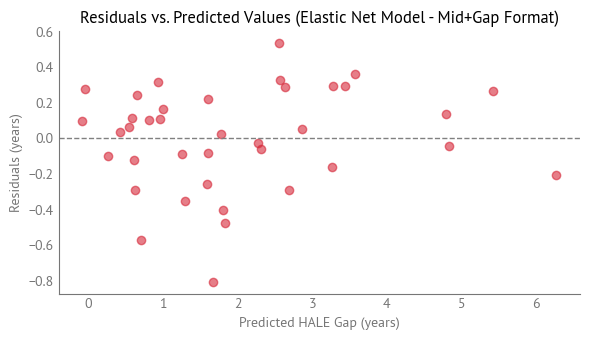

In [21]:
# Residual vs. Predicted values plot
plt.scatter(y_pred, residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Predicted HALE Gap (years)',
         ylabel='Residuals (years)',
         title='Residuals vs. Predicted Values (Elastic Net Model - Mid+Gap Format)')

plt.savefig('jb/figs/residuals_vs_predicted_hale.png', dpi=300, bbox_inches='tight')

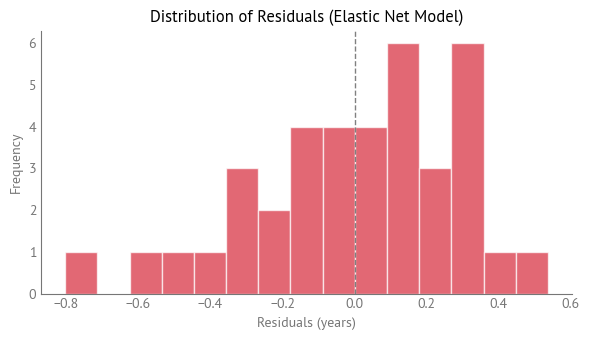

In [22]:
# Histogram of residuals
plt.hist(residuals, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Residuals (years)',
         ylabel='Frequency',
         title='Distribution of Residuals (Elastic Net Model)')

plt.savefig('jb/figs/residuals_distribution_hale.png', dpi=300, bbox_inches='tight')

In [23]:
# Identify potential outliers (residuals > 2 standard deviations)
outlier_threshold = 2 * residuals.std()
outliers = residuals[abs(residuals) > outlier_threshold]

outlier_df = pd.DataFrame({
    'Country': codes_to_country_names(outliers.index),
    'Actual_HALE_Gap': y[outliers.index],
    'Predicted_HALE_Gap': y_pred[outliers.index],
    'Residual': outliers.values,
    'Abs_Residual': abs(outliers.values)
}).sort_values('Abs_Residual', ascending=False)

outlier_df if not outlier_df.empty else "No outliers detected (|residual| > 2 std)"

,Country,Actual_HALE_Gap,Predicted_HALE_Gap,Residual,Abs_Residual
Code,,,,,
DEU,Germany,0.862288,1.665609,-0.80332,0.80332


In [24]:
# Residuals by country (sorted by absolute residual)
residuals_by_country = pd.DataFrame({
    'Country': codes_to_country_names(residuals.index),
    'Actual_HALE_Gap': y.values,
    'Predicted_HALE_Gap': y_pred,
    'Residual': residuals.values,
    'Abs_Residual': abs(residuals.values)
}).sort_values('Abs_Residual', ascending=False)

residuals_by_country.head(10)

,Country,Actual_HALE_Gap,Predicted_HALE_Gap,Residual,Abs_Residual
Code,,,,,
DEU,Germany,0.862288,1.665609,-0.803320,0.803320
SWE,Sweden,0.134025,0.705521,-0.571496,0.571496
CZE,Czechia,3.091037,2.554253,0.536783,0.536783
AUT,Austria,1.363167,1.835271,-0.472103,0.472103
CHL,Chile,1.408306,1.806877,-0.398571,0.398571
SVK,Slovakia,3.930964,3.571624,0.359340,0.359340
BEL,Belgium,0.940556,1.293361,-0.352805,0.352805
COL,Colombia,2.892291,2.563481,0.328810,0.328810
CAN,Canada,1.254710,0.937965,0.316745,0.316745


In [25]:
# Write residuals by country table to HTML
write_html_table(residuals_by_country, 'jb/tables/residuals_by_country_hale.html')

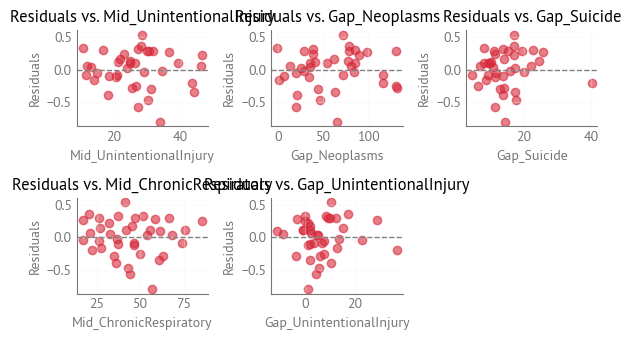

In [26]:
# Check for patterns: plot residuals vs. each predictor (top predictors by absolute coefficient)
# Get top predictors by absolute coefficient value
coef_abs = pd.Series(elastic_net_best_model.named_steps['elasticnet'].coef_, index=X.columns).abs()
top_predictors = coef_abs.nlargest(5).index.values

fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for i, pred in enumerate(top_predictors):
    if i < len(axes):
        axes[i].scatter(X[pred], residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
        axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=1)
        axes[i].set_xlabel(pred)
        axes[i].set_ylabel('Residuals')
        axes[i].set_title(f'Residuals vs. {pred}')
        axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(top_predictors), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('jb/figs/residuals_vs_predictors_hale.png', dpi=300, bbox_inches='tight')

## Importance Analysis


In [27]:
# Create dictionary mapping predictor names to Elastic Net coefficients
# This makes it easier to look up coefficients by predictor name
elastic_net_coefs_dict = dict(zip(X.columns, elastic_net_best_model.named_steps['elasticnet'].coef_))

In [28]:
# Feature importance = |coefficient| × std(predictor)
# This measures the contribution of each predictor to the HALE gap variation
# Since predictors are standardized, we multiply by the original standard deviation
# to get importance on the original scale

predictor_importance = []

for predictor in X.columns:
    coef = elastic_net_coefs_dict.get(predictor, 0)
    
    # Get the original (unstandardized) standard deviation
    # The scaler was fit on X, so we can get the std from predictors DataFrame
    if predictor in predictors.columns:
        std_original = predictors[predictor].std()
        importance = abs(coef) * std_original
    else:
        std_original = 0
        importance = 0
    
    predictor_importance.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Std_Original': std_original,
        'Importance': importance
    })

importance_df = pd.DataFrame(predictor_importance).sort_values('Importance', ascending=False)
importance_df

,Predictor,Coefficient,Std_Original,Importance
19,Mid_Neoplasms,0.213345,71.863008,15.331647
18,Gap_Neoplasms,0.344777,37.200265,12.825779
11,Mid_Cardiovascular,0.032889,159.355803,5.240996
3,Mid_ChronicRespiratory,-0.255945,17.260494,4.417744
5,Mid_UnintentionalInjury,-0.354215,9.526374,3.374387
14,Gap_Homicide,0.231818,10.702805,2.481103
4,Gap_UnintentionalInjury,0.247515,9.343600,2.312682
16,Gap_Suicide,0.287401,6.615119,1.901189
15,Mid_Homicide,0.217270,6.628072,1.440083
20,Gap_LiverDiseaseDeathRate,0.147692,8.540757,1.261404


In [29]:
# Write non-zero importance rows to HTML
importance_nonzero = importance_df[importance_df['Importance'] != 0].copy()
write_html_table(importance_nonzero, 'jb/tables/predictor_importance_hale.html')
importance_nonzero

,Predictor,Coefficient,Std_Original,Importance
19,Mid_Neoplasms,0.213345,71.863008,15.331647
18,Gap_Neoplasms,0.344777,37.200265,12.825779
11,Mid_Cardiovascular,0.032889,159.355803,5.240996
3,Mid_ChronicRespiratory,-0.255945,17.260494,4.417744
5,Mid_UnintentionalInjury,-0.354215,9.526374,3.374387
14,Gap_Homicide,0.231818,10.702805,2.481103
4,Gap_UnintentionalInjury,0.247515,9.343600,2.312682
16,Gap_Suicide,0.287401,6.615119,1.901189
15,Mid_Homicide,0.217270,6.628072,1.440083
20,Gap_LiverDiseaseDeathRate,0.147692,8.540757,1.261404


### Visualize Predictor Importance

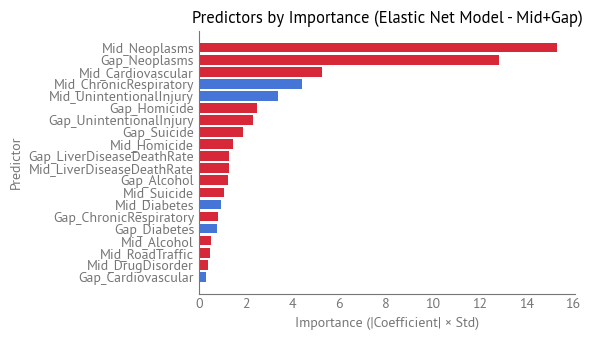

In [30]:
# Create bar chart of all predictors with non-zero coefficients by importance
non_zero_importance = importance_df[importance_df['Importance'] != 0].copy()

colors = [AIBM_COLORS['crimson'] if x > 0 else AIBM_COLORS['blue'] 
          for x in non_zero_importance['Coefficient']]
plt.barh(range(len(non_zero_importance)), non_zero_importance['Importance'], color=colors)
plt.yticks(range(len(non_zero_importance)), non_zero_importance['Predictor'])
plt.gca().invert_yaxis()
decorate(xlabel='Importance (|Coefficient| × Std)',
         ylabel='Predictor',
         title='Predictors by Importance (Elastic Net Model - Mid+Gap)')

plt.savefig('jb/figs/predictor_importance_hale.png', dpi=300, bbox_inches='tight')

### Importance by Indicator

In [31]:
# Extract indicator names from Mid_ and Gap_ columns
all_indicators = set()
for col in predictors.columns:
    if col.startswith('Mid_'):
        indicator_name = col[4:]  # Remove 'Mid_' prefix
        all_indicators.add(indicator_name)
    elif col.startswith('Gap_'):
        indicator_name = col[4:]  # Remove 'Gap_' prefix
        all_indicators.add(indicator_name)

# Indicators with both Mid and Gap (most indicators)
mid_gap_indicators = sorted([ind for ind in all_indicators 
                             if f'Mid_{ind}' in predictors.columns and f'Gap_{ind}' in predictors.columns])

# Female-only indicators (e.g., MaternalMortality)
# Automatically include if present in predictors
female_only_indicators = []
if 'MaternalMortality_Female' in predictors.columns:
    female_only_indicators = ['MaternalMortality']
female_only_indicators

[]

In [32]:
# Aggregate importance by indicator (sum of Mid and Gap importance)
indicator_importance = {}

for indicator in mid_gap_indicators:
    mid_col = f'Mid_{indicator}'
    gap_col = f'Gap_{indicator}'
    
    mid_imp = importance_df[importance_df['Predictor'] == mid_col]['Importance'].values
    gap_imp = importance_df[importance_df['Predictor'] == gap_col]['Importance'].values
    
    if len(mid_imp) > 0 and len(gap_imp) > 0:
        total_importance = mid_imp[0] + gap_imp[0]
        indicator_importance[indicator] = {
            'Mid_Importance': mid_imp[0],
            'Gap_Importance': gap_imp[0],
            'Total_Importance': total_importance
        }

# Add female-only indicators (if any)
for indicator in female_only_indicators:
    # Check for any column matching this indicator
    matching_cols = [col for col in predictors.columns if indicator in col]
    print(matching_cols)
    if matching_cols:
        col = matching_cols[0]
        col_imp = importance_df[importance_df['Predictor'] == col]['Importance'].values
        if len(col_imp) > 0:
            indicator_importance[indicator] = {
                'Mid_Importance': np.nan,
                'Gap_Importance': np.nan,
                'Total_Importance': col_imp[0]
            }

indicator_importance_df = pd.DataFrame(indicator_importance).T
indicator_importance_df = indicator_importance_df.sort_values('Total_Importance', ascending=False)
indicator_importance_df

,Mid_Importance,Gap_Importance,Total_Importance
Neoplasms,15.331647,12.825779,28.157426
UnintentionalInjury,3.374387,2.312682,5.687068
Cardiovascular,5.240996,0.305770,5.546766
ChronicRespiratory,4.417744,0.801434,5.219179
Homicide,1.440083,2.481103,3.921186
Suicide,1.054686,1.901189,2.955875
LiverDiseaseDeathRate,1.260879,1.261404,2.522283
Alcohol,0.490779,1.234396,1.725175
Diabetes,0.933675,0.754899,1.688574
RoadTraffic,0.468393,0.000000,0.468393


In [33]:
# Write indicator importance table to HTML
indicator_importance_formatted = indicator_importance_df.reset_index().rename(columns={'index': 'Indicator'})
write_html_table(indicator_importance_formatted, 'jb/tables/indicator_importance_hale.html')
indicator_importance_formatted

,Indicator,Mid_Importance,Gap_Importance,Total_Importance
0,Neoplasms,15.331647,12.825779,28.157426
1,UnintentionalInjury,3.374387,2.312682,5.687068
2,Cardiovascular,5.240996,0.305770,5.546766
3,ChronicRespiratory,4.417744,0.801434,5.219179
4,Homicide,1.440083,2.481103,3.921186
5,Suicide,1.054686,1.901189,2.955875
6,LiverDiseaseDeathRate,1.260879,1.261404,2.522283
7,Alcohol,0.490779,1.234396,1.725175
8,Diabetes,0.933675,0.754899,1.688574
9,RoadTraffic,0.468393,0.000000,0.468393


### Visualize Indicator Importance

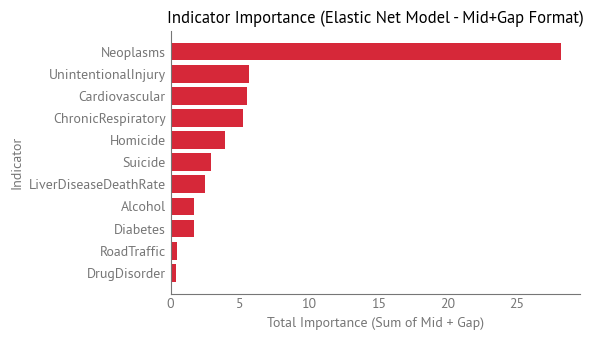

In [34]:
# Bar chart of indicator-level importance
colors_bar = [AIBM_COLORS['crimson'] for _ in range(len(indicator_importance_df))]
plt.barh(range(len(indicator_importance_df)), indicator_importance_df['Total_Importance'], 
         color=colors_bar)
plt.yticks(range(len(indicator_importance_df)), indicator_importance_df.index)
plt.gca().invert_yaxis()
decorate(xlabel='Total Importance (Sum of Mid + Gap)',
         ylabel='Indicator',
         title='Indicator Importance (Elastic Net Model - Mid+Gap Format)')

plt.savefig('jb/figs/indicator_importance_hale.png', dpi=300, bbox_inches='tight')

## Statsmodels Linear Regression with Selected Predictors

In [35]:
import statsmodels.api as sm

# Extract predictors with non-zero coefficients from Elastic Net
elastic_net_coefs = elastic_net_best_model.named_steps['elasticnet'].coef_
non_zero_mask = elastic_net_coefs != 0
selected_predictors = X.columns[non_zero_mask].tolist()

print(f"Selected predictors (non-zero Elastic Net coefficients): {len(selected_predictors)}")
print(selected_predictors)

Selected predictors (non-zero Elastic Net coefficients): 20
['Gap_Alcohol', 'Mid_Alcohol', 'Gap_ChronicRespiratory', 'Mid_ChronicRespiratory', 'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury', 'Mid_RoadTraffic', 'Gap_Diabetes', 'Mid_Diabetes', 'Gap_Cardiovascular', 'Mid_Cardiovascular', 'Mid_DrugDisorder', 'Gap_Homicide', 'Mid_Homicide', 'Gap_Suicide', 'Mid_Suicide', 'Gap_Neoplasms', 'Mid_Neoplasms', 'Gap_LiverDiseaseDeathRate', 'Mid_LiverDiseaseDeathRate']


In [36]:
# Standardize the selected predictors to match Elastic Net preprocessing
# Create a new StandardScaler and fit it only on the selected predictors
# (We can't reuse the Elastic Net scaler because it was fit on all predictors)
from sklearn.preprocessing import StandardScaler

# Create subset of X with only selected predictors
X_selected = X[selected_predictors].copy()

# Create and fit a new scaler on the selected predictors only
ols_scaler = StandardScaler()
X_selected_standardized = pd.DataFrame(
    ols_scaler.fit_transform(X_selected),
    index=X_selected.index,
    columns=X_selected.columns
)

# Add constant term for intercept
X_selected_with_const = sm.add_constant(X_selected_standardized)

# Fit OLS regression on standardized predictors
ols_model = sm.OLS(y, X_selected_with_const).fit()

# Display summary
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               HALE_gap   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     31.43
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.05e-09
Time:                        16:35:32   Log-Likelihood:                -2.2042
No. Observations:                  38   AIC:                             46.41
Df Residuals:                      17   BIC:                             80.80
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         1.9775      0.062     31.796      0.000       1.846       2.109
Gap_Alcohol                  -0.0460      0.673     -0.068      0.946      -1.465       1.373
Mid_Alcohol                   0.3366      0.655      0.514      0.614      -1.045       1.718
Gap_ChronicRespiratory        0.0876      0.150      0.585      0.566      -0.228       0.403
Mid_ChronicRespiratory       -0.4190      0.144     -2.905      0.010      -0.723      -0.115
Gap_UnintentionalInjury       0.0099      0.235      0.042      0.967      -0.486       0.506
Mid_UnintentionalInjury      -0.6011      0.174     -3.462      0.003      -0.967      -0.235
Mid_RoadTraffic               0.0649      0.158      0.412      0.686      -0.267       0.397
Gap_Diabetes                 -0.3497      0.118     -2.959      0.009      -0.599      -0.100
Mid_Diabetes                 -0.1778      0.120     -1.479      0.157      -0.432       0.076
Gap_Cardiovascular            0.0494      0.200      0.247      0.808      -0.373       0.472
Mid_Cardiovascular            0.0105      0.234      0.045      0.965      -0.483       0.504
Mid_DrugDisorder              0.1658      0.136      1.215      0.241      -0.122       0.454
Gap_Homicide                 -0.4975      2.963     -0.168      0.869      -6.750       5.755
Mid_Homicide                  1.1393      3.047      0.374      0.713      -5.289       7.568
Gap_Suicide                   0.4683      0.337      1.389      0.183      -0.243       1.180
Mid_Suicide                   0.1577      0.259      0.609      0.550      -0.388       0.704
Gap_Neoplasms                 0.3903      0.213      1.834      0.084      -0.059       0.839
Mid_Neoplasms                 0.4789      0.254      1.883      0.077      -0.058       1.015
Gap_LiverDiseaseDeathRate     0.1464      0.355      0.413      0.685      -0.602       0.895
Mid_LiverDiseaseDeathRate     0.2165      0.398      0.544      0.594      -0.623       1.056
==============================================================================
Omnibus:                        6.487   Durbin-Watson:                   2.809
Prob(Omnibus):                  0.039   Jarque-Bera (JB):                5.307
Skew:                          -0.666   Prob(JB):                       0.0704
Kurtosis:                       4.256   Cond. No.                         186.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
# Compare coefficients: Elastic Net vs OLS (both on standardized scale)
# Note: Both models now use standardized predictors, so coefficients are directly comparable
coef_comparison_selected = pd.DataFrame({
    'Predictor': selected_predictors,
    'ElasticNet_Coefficient': elastic_net_coefs[non_zero_mask],
    'OLS_Coefficient': ols_model.params[selected_predictors].values,
    'OLS_PValue': ols_model.pvalues[selected_predictors].values,
    'OLS_StdErr': ols_model.bse[selected_predictors].values
})

coef_comparison_selected['Difference'] = coef_comparison_selected['OLS_Coefficient'] - coef_comparison_selected['ElasticNet_Coefficient']
coef_comparison_selected = coef_comparison_selected.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
coef_comparison_selected

,Predictor,ElasticNet_Coefficient,OLS_Coefficient,OLS_PValue,OLS_StdErr,Difference
5,Mid_UnintentionalInjury,-0.354215,-0.601098,0.002980,0.173629,-0.246883
16,Gap_Neoplasms,0.344777,0.390331,0.084247,0.212851,0.045555
14,Gap_Suicide,0.287401,0.468288,0.182900,0.337253,0.180888
3,Mid_ChronicRespiratory,-0.255945,-0.418967,0.009858,0.144223,-0.163021
4,Gap_UnintentionalInjury,0.247515,0.009939,0.966794,0.235265,-0.237576
12,Gap_Homicide,0.231818,-0.497532,0.868646,2.963340,-0.729350
7,Gap_Diabetes,-0.228147,-0.349700,0.008798,0.118201,-0.121553
13,Mid_Homicide,0.217270,1.139298,0.713082,3.046852,0.922028
17,Mid_Neoplasms,0.213345,0.478862,0.076956,0.254334,0.265516
0,Gap_Alcohol,0.211845,-0.045970,0.946322,0.672790,-0.257815


In [38]:
# Write Elastic Net vs OLS coefficient comparison to HTML
write_html_table(coef_comparison_selected, 'jb/tables/elasticnet_ols_coefficient_comparison_hale.html')

In [39]:
# Compare model performance
ols_r2 = ols_model.rsquared
ols_adj_r2 = ols_model.rsquared_adj
ols_mae = mean_absolute_error(y, ols_model.fittedvalues)

performance_comparison = pd.DataFrame({
    'Model': ['Elastic Net', 'OLS (Selected Predictors)'],
    'R²': [r2_full, ols_r2],
    'Adjusted R²': [np.nan, ols_adj_r2],
    'MAE': [mean_absolute_error(y, y_pred), ols_mae],
    'Number of Predictors': [len(X.columns), len(selected_predictors)],
    'Non-Zero Coefficients': [np.sum(elastic_net_coefs != 0), len(selected_predictors)]
})

performance_comparison

,Model,R²,Adjusted R²,MAE,Number of Predictors,Non-Zero Coefficients
0,Elastic Net,0.967694,NaN,0.227777,22,20
1,OLS (Selected Predictors),0.973669,0.942692,0.195656,20,20


In [40]:
# Write performance comparison table to HTML
write_html_table(performance_comparison, 'jb/tables/performance_comparison_hale.html')

## Country-Level Predictions Comparison

In [41]:
# Generate predictions from both models
# Note: Both models use standardized predictors, so we need to standardize X for OLS predictions
elastic_net_predictions = elastic_net_best_model.predict(X)
ols_predictions = ols_model.predict(X_selected_with_const)  # Already standardized above

# Create comparison table
predictions_comparison = pd.DataFrame({
    'Country': codes_to_country_names(y.index),
    'Actual_HALE_Gap': y.values,
    'ElasticNet_Prediction': elastic_net_predictions,
    'OLS_Prediction': ols_predictions,
    'EN_Residual': y.values - elastic_net_predictions,
    'OLS_Residual': y.values - ols_predictions,
    'Prediction_Difference': ols_predictions - elastic_net_predictions,
    'Abs_Prediction_Difference': np.abs(ols_predictions - elastic_net_predictions)
})

# Sort by absolute prediction difference to see where models disagree most
predictions_comparison = predictions_comparison.sort_values('Abs_Prediction_Difference', ascending=False)

predictions_comparison

,Country,Actual_HALE_Gap,ElasticNet_Prediction,OLS_Prediction,EN_Residual,OLS_Residual,Prediction_Difference,Abs_Prediction_Difference
Code,,,,,,,,
TUR,Türkiye,1.169973,1.258719,1.004752,-0.088746,0.165222,-0.253968,0.253968
BEL,Belgium,0.940556,1.293361,1.048846,-0.352805,-0.108290,-0.244515,0.244515
POL,Poland,4.929800,4.793864,5.021364,0.135937,-0.091564,0.227500,0.227500
COL,Colombia,2.892291,2.563481,2.790110,0.328810,0.102181,0.226629,0.226629
CHL,Chile,1.408306,1.806877,1.598886,-0.398571,-0.190580,-0.207992,0.207992
JPN,Japan,2.928847,2.638559,2.842173,0.290288,0.086674,0.203614,0.203614
KOR,South Korea,3.564595,3.269902,3.437489,0.294694,0.127106,0.167588,0.167588
GBR,United Kingdom,0.694553,0.582319,0.739307,0.112234,-0.044753,0.156987,0.156987
NOR,Norway,0.238734,-0.039671,-0.193428,0.278405,0.432162,-0.153757,0.153757


In [42]:
# Write predictions comparison table to HTML
write_html_table(predictions_comparison, 'jb/tables/predictions_comparison_hale.html')

In [43]:
# Summary statistics of prediction differences
print("Summary of Prediction Differences (OLS - Elastic Net):")
print("="*60)
print(f"Mean difference: {predictions_comparison['Prediction_Difference'].mean():.4f} years")
print(f"Median difference: {predictions_comparison['Prediction_Difference'].median():.4f} years")
print(f"Std deviation: {predictions_comparison['Prediction_Difference'].std():.4f} years")
print(f"Min difference: {predictions_comparison['Prediction_Difference'].min():.4f} years")
print(f"Max difference: {predictions_comparison['Prediction_Difference'].max():.4f} years")
print(f"Mean absolute difference: {predictions_comparison['Abs_Prediction_Difference'].mean():.4f} years")
print(f"\nCountries with largest prediction differences:")
predictions_comparison[['Country', 'Actual_HALE_Gap', 'ElasticNet_Prediction', 
                              'OLS_Prediction', 'Prediction_Difference']].head(10)

Summary of Prediction Differences (OLS - Elastic Net):
Mean difference: 0.0000 years
Median difference: 0.0053 years
Std deviation: 0.1238 years
Min difference: -0.2540 years
Max difference: 0.2275 years
Mean absolute difference: 0.0992 years

Countries with largest prediction differences:


,Country,Actual_HALE_Gap,ElasticNet_Prediction,OLS_Prediction,Prediction_Difference
Code,,,,,
TUR,Türkiye,1.169973,1.258719,1.004752,-0.253968
BEL,Belgium,0.940556,1.293361,1.048846,-0.244515
POL,Poland,4.929800,4.793864,5.021364,0.227500
COL,Colombia,2.892291,2.563481,2.790110,0.226629
CHL,Chile,1.408306,1.806877,1.598886,-0.207992
JPN,Japan,2.928847,2.638559,2.842173,0.203614
KOR,South Korea,3.564595,3.269902,3.437489,0.167588
GBR,United Kingdom,0.694553,0.582319,0.739307,0.156987
NOR,Norway,0.238734,-0.039671,-0.193428,-0.153757


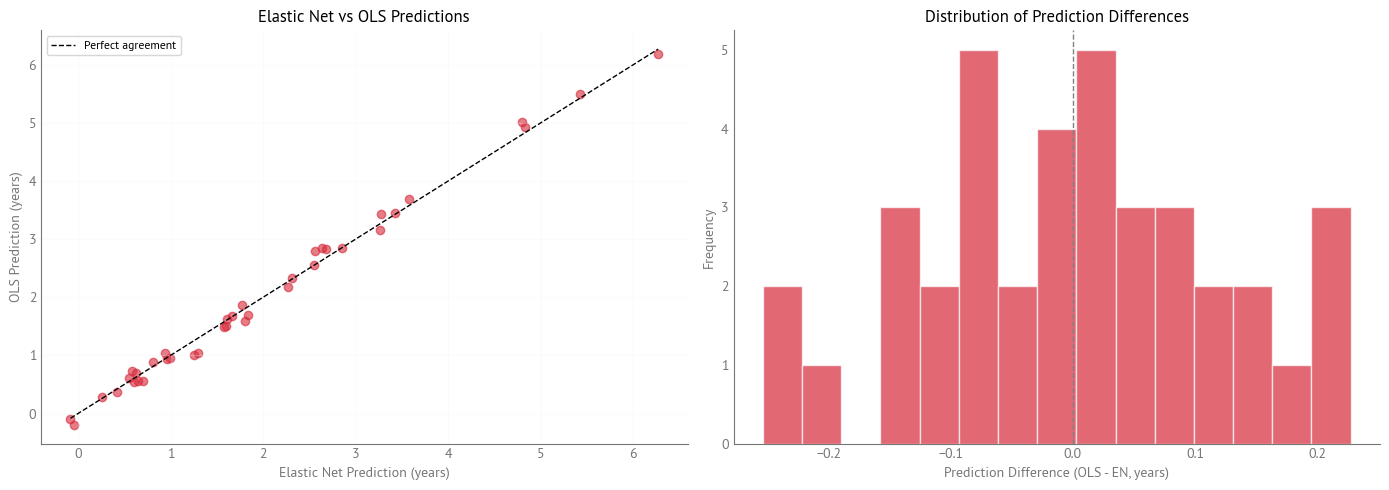

In [44]:
# Visualize prediction differences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: EN vs OLS predictions
axes[0].scatter(elastic_net_predictions, ols_predictions, 
                color=AIBM_COLORS['crimson'], alpha=0.6)
axes[0].plot([elastic_net_predictions.min(), elastic_net_predictions.max()],
             [elastic_net_predictions.min(), elastic_net_predictions.max()],
             'k--', linewidth=1, label='Perfect agreement')
axes[0].set_xlabel('Elastic Net Prediction (years)')
axes[0].set_ylabel('OLS Prediction (years)')
axes[0].set_title('Elastic Net vs OLS Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of prediction differences
axes[1].hist(predictions_comparison['Prediction_Difference'], bins=15,
             color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Prediction Difference (OLS - EN, years)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Differences')

plt.tight_layout()
plt.savefig('jb/figs/predictions_comparison_hale.png', dpi=300, bbox_inches='tight')

In [45]:
# Compare residuals from both models
residuals_comparison = pd.DataFrame({
    'Country': codes_to_country_names(y.index),
    'EN_Residual': y.values - elastic_net_predictions,
    'OLS_Residual': y.values - ols_predictions,
    'Residual_Difference': (y.values - ols_predictions) - (y.values - elastic_net_predictions)
})

residuals_comparison = residuals_comparison.sort_values('Residual_Difference', key=abs, ascending=False)
print("Residual Comparison (Actual - Predicted):")
print("="*60)
print(f"EN MAE: {mean_absolute_error(y, elastic_net_predictions):.4f} years")
print(f"OLS MAE: {mean_absolute_error(y, ols_predictions):.4f} years")
print(f"\nCountries with largest residual differences:")
residuals_comparison.head(10)

Residual Comparison (Actual - Predicted):
EN MAE: 0.2278 years
OLS MAE: 0.1957 years

Countries with largest residual differences:


,Country,EN_Residual,OLS_Residual,Residual_Difference
Code,,,,
TUR,Türkiye,-0.088746,0.165222,0.253968
BEL,Belgium,-0.352805,-0.108290,0.244515
POL,Poland,0.135937,-0.091564,-0.227500
COL,Colombia,0.328810,0.102181,-0.226629
CHL,Chile,-0.398571,-0.190580,0.207992
JPN,Japan,0.290288,0.086674,-0.203614
KOR,South Korea,0.294694,0.127106,-0.167588
GBR,United Kingdom,0.112234,-0.044753,-0.156987
NOR,Norway,0.278405,0.432162,0.153757


## Counterfactual Analysis

Counterfactual analysis allows us to answer "what if" questions: What would happen to a country's predicted healthy life expectancy gap if we adjusted a gap predictor to the best attainable value?

For each gap predictor, we find the best case:
- If the current gap is positive (Male > Female), we find the country with the smallest gap (minimum)
- If the current gap is negative (Female > Male), we find the country with the largest gap (maximum, most positive)

To achieve that target gap, we adjust either male or female values:
- If the gap is positive (Male > Female), we bring men toward women's level
- If the gap is negative (Female > Male), we bring women toward men's level

After adjusting Male/Female values, we recompute Mid and Gap values, then use the model to generate the counterfactual prediction.

In [46]:
# Find minimum and maximum gap for each gap predictor across all countries
gap_predictors = [col for col in X.columns if col.startswith('Gap_')]
gap_extremes = {}
for gap_pred in gap_predictors:
    gap_data = X[gap_pred].dropna()
    gap_extremes[gap_pred] = {
        'min_gap': gap_data.min(),
        'min_country': gap_data.idxmin(),
        'max_gap': gap_data.max(),
        'max_country': gap_data.idxmax()
    }

gap_extremes_df = pd.DataFrame(gap_extremes).T
gap_extremes_df

,min_gap,min_country,max_gap,max_country
Gap_Alcohol,0.305501,COL,23.599994,SVN
Gap_ChronicRespiratory,-19.33971,ISL,34.055132,JPN
Gap_UnintentionalInjury,-11.173752,NLD,37.064721,LTU
Gap_RoadTraffic,2.03739,ISL,22.025433,CRI
Gap_Diabetes,-9.828557,LVA,5.500981,USA
Gap_Cardiovascular,-123.902885,LVA,25.551737,IRL
Gap_DrugDisorder,0.022645,JPN,15.97672,USA
Gap_Homicide,-0.062157,NOR,47.465542,MEX
Gap_Suicide,4.510746,TUR,40.152181,LTU
Gap_Neoplasms,-0.787975,COL,131.66036,PRT


In [47]:
def counterfactual_predictions(country, gap_predictor):
    """
    Generate counterfactual prediction by adjusting Male/Female values to achieve best case gap.
    
    Parameters:
    -----------
    country : str
        Country code (e.g., 'USA', 'GBR')
    gap_predictor : str
        Name of the gap predictor column (e.g., 'Gap_Alcohol')
        
    Returns:
    --------
    dict
        Dictionary with counterfactual results including original and adjusted values
    """
    # Extract indicator name from gap predictor (e.g., 'Gap_Alcohol' -> 'Alcohol')
    indicator_name = gap_predictor.replace('Gap_', '')
    
    # Get original Male and Female values from predictors_full
    male_col = f'{indicator_name}_Male'
    female_col = f'{indicator_name}_Female'
    
    original_male = predictors_full.loc[country, male_col]
    original_female = predictors_full.loc[country, female_col]
    original_gap = original_male - original_female
    
    # Determine target gap based on current gap sign
    # If current gap is positive, find minimum gap (best case: smallest positive gap)
    # If current gap is negative, find maximum gap (best case: largest positive gap)
    if original_gap > 0:
        target_gap = gap_extremes[gap_predictor]['min_gap']
        target_country = gap_extremes[gap_predictor]['min_country']
    else:
        target_gap = gap_extremes[gap_predictor]['max_gap']
        target_country = gap_extremes[gap_predictor]['max_country']
    
    # If target gap has opposite sign of current gap, set target to zero
    if (original_gap > 0 and target_gap < 0) or (original_gap < 0 and target_gap > 0):
        target_gap = 0.0
        target_country = ""
    
    # Determine which direction to adjust
    if original_gap > 0:
        # Positive gap: bring men toward women's level
        adjusted_male = original_female + target_gap
        adjusted_female = original_female
    else:
        # Negative gap: bring women toward men's level
        adjusted_male = original_male
        adjusted_female = original_male - target_gap
    
    # Recompute Mid and Gap from adjusted Male/Female
    adjusted_mid = (adjusted_male + adjusted_female) / 2
    adjusted_gap = adjusted_male - adjusted_female
    
    # Get all current predictor values for the country
    counterfactual_data = X.loc[country].copy()
    
    # Update Mid and Gap for this indicator
    mid_col = f'Mid_{indicator_name}'
    counterfactual_data[mid_col] = adjusted_mid
    counterfactual_data[gap_predictor] = adjusted_gap
    
    # Generate prediction
    original_prediction = primary_model.predict(X.loc[country].to_frame().T)[0]
    counterfactual_prediction = primary_model.predict(counterfactual_data.to_frame().T)[0]
    
    return {
        'country': country,
        'indicator': indicator_name,
        'original_male': original_male,
        'original_female': original_female,
        'original_gap': original_gap,
        'target_gap': target_gap,
        'adjusted_male': adjusted_male,
        'adjusted_female': adjusted_female,
        'adjusted_mid': adjusted_mid,
        'adjusted_gap': adjusted_gap,
        'original_prediction': original_prediction,
        'counterfactual_prediction': counterfactual_prediction,
        'change_in_gap': counterfactual_prediction - original_prediction,
        'target_country': target_country
    }

In [48]:
# Example: Counterfactual analysis for USA with Alcohol gap
test_country = 'USA'
test_predictor = 'Gap_Alcohol'

result = counterfactual_predictions(test_country, test_predictor)

# Display summary
print(f"Counterfactual Analysis: {code_to_who_country.get(test_country, test_country)} ({test_country})")
print(f"Indicator: {result['indicator']}")
print(f"\nOriginal values:")
print(f"  Male: {result['original_male']:.3f}")
print(f"  Female: {result['original_female']:.3f}")
print(f"  Gap (Male - Female): {result['original_gap']:.3f}")
if result['target_country']:
    if result['original_gap'] > 0:
        gap_type = "minimum"
    else:
        gap_type = "maximum"
    print(f"\nTarget gap ({gap_type} observed, from {code_to_who_country.get(result['target_country'], result['target_country'])}): {result['target_gap']:.3f}")
else:
    print(f"\nTarget gap (set to zero because best case has opposite sign): {result['target_gap']:.3f}")
print(f"\nAdjusted values to achieve target gap:")
print(f"  Male: {result['adjusted_male']:.3f}")
print(f"  Female: {result['adjusted_female']:.3f}")
print(f"  Gap (Male - Female): {result['adjusted_gap']:.3f}")
print(f"\nPredictions:")
print(f"  Original: {result['original_prediction']:.3f} years")
print(f"  Counterfactual: {result['counterfactual_prediction']:.3f} years")
print(f"  Change: {result['change_in_gap']:.3f} years")

Counterfactual Analysis: United States (USA)
Indicator: Alcohol

Original values:
  Male: 8.439
  Female: 2.895
  Gap (Male - Female): 5.544

Target gap (minimum observed, from Colombia): 0.306

Adjusted values to achieve target gap:
  Male: 3.201
  Female: 2.895
  Gap (Male - Female): 0.306

Predictions:
  Original: 1.775 years
  Counterfactual: 1.502 years
  Change: -0.273 years


In [49]:
# Generate counterfactuals for all gap predictors for a country
def counterfactuals_for_country(country):
    """
    Generate counterfactual predictions for all gap predictors for a given country.
    
    Returns DataFrame with results sorted by importance (descending).
    """
    results = []
    for gap_pred in gap_predictors:
        try:
            result = counterfactual_predictions(country, gap_pred)
            indicator_name = result['indicator']
            
            # Get importance for this indicator
            if indicator_name in indicator_importance_df.index:
                importance = indicator_importance_df.loc[indicator_name, 'Total_Importance']
            else:
                importance = 0.0
            
            # Get country name for target country
            target_country_code = result['target_country']
            if target_country_code:
                target_country_name = code_to_who_country.get(target_country_code, target_country_code)
            else:
                target_country_name = ""
            
            results.append({
                'Indicator': indicator_name,
                'Current gap': result['original_gap'],
                'Target gap': result['target_gap'],
                'Target Country': target_country_name,
                'Change in HALE gap': result['change_in_gap'],
                'Importance': importance
            })
        except (KeyError, ValueError):
            # Skip if indicator doesn't have Male/Female columns (e.g., MaternalMortality)
            continue
    
    df = pd.DataFrame(results)
    # Sort by importance (descending), then select only the columns we want
    df = df.sort_values('Importance', ascending=False)
    df = df[['Indicator', 'Current gap', 'Target gap', 'Target Country', 'Change in HALE gap']]
    return df

# Example: All counterfactuals for USA
usa_counterfactuals = counterfactuals_for_country('USA')
usa_counterfactuals

,Indicator,Current gap,Target gap,Target Country,Change in HALE gap
9,Neoplasms,25.657586,0.000000,,-0.279587
2,UnintentionalInjury,5.255187,0.000000,,-0.042068
5,Cardiovascular,19.396726,0.000000,,0.001786
1,ChronicRespiratory,-5.823940,0.000000,,0.086865
7,Homicide,7.291020,0.000000,,-0.281145
8,Suicide,17.255473,4.510746,Türkiye,-0.801287
10,LiverDiseaseDeathRate,9.053963,1.287206,Iceland,-0.205442
0,Alcohol,5.543927,0.305501,Colombia,-0.273329
4,Diabetes,5.500981,0.000000,,0.408967
3,RoadTraffic,11.161247,2.037390,Iceland,-0.165001


In [50]:
# Write counterfactual table to HTML
write_html_table(usa_counterfactuals, 'jb/tables/counterfactuals_usa_hale.html')

In [51]:
target['USA']

1.8007769799999949

In [52]:
gap_closer = usa_counterfactuals['Change in HALE gap'] < 0
usa_counterfactuals.loc[gap_closer]

,Indicator,Current gap,Target gap,Target Country,Change in HALE gap
9,Neoplasms,25.657586,0.000000,,-0.279587
2,UnintentionalInjury,5.255187,0.000000,,-0.042068
7,Homicide,7.291020,0.000000,,-0.281145
8,Suicide,17.255473,4.510746,Türkiye,-0.801287
10,LiverDiseaseDeathRate,9.053963,1.287206,Iceland,-0.205442
0,Alcohol,5.543927,0.305501,Colombia,-0.273329
3,RoadTraffic,11.161247,2.037390,Iceland,-0.165001
6,DrugDisorder,15.976720,0.022645,Japan,-0.206411


In [53]:
total = usa_counterfactuals.loc[gap_closer, 'Change in HALE gap'].sum()
total

-2.254269350317644

In [54]:
total / target['USA'] * 100

-125.18315012654429

In [55]:
gap_widener = usa_counterfactuals['Change in HALE gap'] > 0
usa_counterfactuals.loc[gap_widener]

,Indicator,Current gap,Target gap,Target Country,Change in HALE gap
5,Cardiovascular,19.396726,0.0,,0.001786
1,ChronicRespiratory,-5.823940,0.0,,0.086865
4,Diabetes,5.500981,0.0,,0.408967


In [56]:
usa_counterfactuals.loc[gap_widener, 'Change in HALE gap'].sum()

0.49761831280948976

This is based on conservative assumptions:

* Only the gap variables are causal -- for the overall rate variables, we're not sure about the nature of the relationship

* It might not be attainable to close all gaps completely, but we take other countries as evidence: if they have eliminated or remove a gap, that's evidence it's possible. If they are closer to zero, that evidence the gap can be reduced to the level they have achieved.

In [57]:
from utils import beep

beep()